In [1]:
#1️⃣ Load the Dataset

import pandas as pd

# Load the dataset
df = pd.read_csv("creditcard.csv")

# Display first few rows
print(df.head())


   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [2]:
#2️⃣ Understand the Dataset Structure
# Get dataset info
print(df.info())

# Check for missing values
print(df.isnull().sum())

# See summary statistics
print(df.describe())




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [3]:
#3️⃣ Check Data Imbalance
# Count fraud vs non-fraud transactions
print(df["Class"].value_counts())

# Percentage of fraud cases
fraud_ratio = df["Class"].value_counts(normalize=True) * 100
print(f"Fraud cases: {fraud_ratio[1]:.4f}%")


Class
0    284315
1       492
Name: count, dtype: int64
Fraud cases: 0.1727%


we likely see fraud cases make up less than 1% of all transactions. This is why we need SMOTE or undersampling (coming up next!).
#Next Step
Now that we’ve explored the dataset, we’ll handle the imbalanced data problem using SMOTE (Synthetic Minority Over-sampling Technique).

Handling Imbalanced Data
Since fraud cases are rare (~0.1%), our model might ignore fraud transactions if we don’t balance the data.

There are two main techniques to fix this:

SMOTE (Synthetic Minority Over-sampling Technique) – Creates artificial fraud samples.

Undersampling – Reduces the number of legitimate transactions to match fraud cases.

We’ll try both methods so you understand their impact!


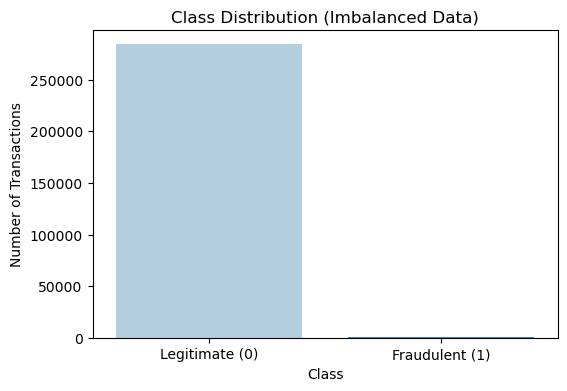

In [4]:
#1️⃣ Check the Data Imbalance
#visualize the imbalance:
import seaborn as sns
import matplotlib.pyplot as plt

# Count fraud vs non-fraud cases
class_counts = df["Class"].value_counts()

# Plot
plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="Blues")
plt.xticks([0, 1], ["Legitimate (0)", "Fraudulent (1)"])
plt.ylabel("Number of Transactions")
plt.title("Class Distribution (Imbalanced Data)")
plt.show()


a huge imbalance, where fraud cases are much fewer than legitimate ones.

#2️⃣ Method 1: SMOTE (Oversampling Fraud Cases)
SMOTE creates synthetic fraud samples by interpolating between existing fraud cases.



In [6]:
#Installing and Applying SMOTE
!pip install imbalanced-learn

#SMOTE
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Separate features and target variable
X = df.drop(columns=["Class"])  # All columns except 'Class'
y = df["Class"]                 # Target variable

# Split data before SMOTE (to prevent data leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE only to training data
smote = SMOTE(sampling_strategy=1.0, random_state=42)  # 1.0 means balance fraud and legit cases
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Check new class balance
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_sm.value_counts())




Before SMOTE: Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


🔹 What happens here?

We split the data first so that test data remains imbalanced (to simulate real-world conditions).

SMOTE() generates new synthetic fraud cases until fraud and legitimate cases are balanced.



#3️⃣ Method 2: Undersampling (Removing Legit Transactions)
Instead of adding synthetic frauds, we can remove some legitimate transactions to match the fraud count.

In [7]:
from imblearn.under_sampling import RandomUnderSampler

# Apply undersampling
rus = RandomUnderSampler(sampling_strategy=1.0, random_state=42)
X_train_us, y_train_us = rus.fit_resample(X_train, y_train)

# Check new class balance
print("Before Undersampling:", y_train.value_counts())
print("After Undersampling:", y_train_us.value_counts())


Before Undersampling: Class
0    227451
1       394
Name: count, dtype: int64
After Undersampling: Class
0    394
1    394
Name: count, dtype: int64


🔹 What happens here?

The number of fraud cases remains the same, but we randomly remove legitimate cases.

It reduces data size, which makes training faster but loses some useful data.

#4️⃣ Choosing Between SMOTE and Undersampling
✅ Use SMOTE when you have few fraud cases and want to retain as much data as possible.
✅ Use Undersampling if you have a very large dataset, so removing some legitimate cases won’t hurt.
✅ Hybrid Approach: Some projects use both (first undersample, then apply SMOTE).



Step 3: Train a Fraud Detection Model
We’ll train a Random Forest classifier first, since it's simple and powerful. Later, we can try Gradient Boosting (like XGBoost).

In [8]:
#1️⃣ Split Data for Training & Testing
from sklearn.model_selection import train_test_split

# Use SMOTE dataset from the previous step
X_train, X_test, y_train, y_test = train_test_split(X_train_sm, y_train_sm, test_size=0.2, random_state=42)

# Check the shape of the datasets
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)





Training data shape: (363921, 30)
Testing data shape: (90981, 30)


🔹 Why split again?

We already split before applying SMOTE, but after SMOTE, we need another split.

80% for training, 20% for testing.



In [10]:
#2️⃣ Train a Random Forest Model
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

print("Model training complete!")




Model training complete!


🔹 What’s happening here?

RandomForestClassifier(n_estimators=100) means we're using 100 decision trees in the model.

.fit(X_train, y_train) trains the model using the balanced dataset.

.predict(X_test) predicts fraud or legitimate transactions for the test set.



In [11]:
#3️⃣ Evaluate Model Performance
#Now, let's check how well our model is performing using Precision, Recall, and F1-score.
from sklearn.metrics import classification_report, confusion_matrix

# Print confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Print classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Confusion Matrix:
 [[45396     9]
 [    1 45575]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     45405
           1       1.00      1.00      1.00     45576

    accuracy                           1.00     90981
   macro avg       1.00      1.00      1.00     90981
weighted avg       1.00      1.00      1.00     90981



🔹 Key Metrics Explained:

Precision – How many detected frauds were actually fraud?

Recall – How many actual frauds did we detect?

F1-score – Balance between precision and recall (higher is better).

🚨 Why not just use Accuracy?
Because the dataset was imbalanced, accuracy can be misleading (e.g., if fraud is 1% of data, a model predicting everything as "legit" gets 99% accuracy but is useless).

In [13]:
#Step 4: Train a Gradient Boosting Model (XGBoost)
#1️⃣ Install XGBoost
#pip install xgboost
#2️⃣ Import XGBoost & Train the Model
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize the XGBoost model
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost model training complete!")




XGBoost model training complete!


 🔹 What’s happening here?

n_estimators=100: The number of trees in the model (more trees = better learning but slower).

learning_rate=0.1: Controls how fast the model learns (lower = slower but better generalization).

max_depth=6: The maximum depth of each decision tree (deeper trees = more complex models).



In [14]:
#3️⃣ Evaluate the XGBoost Model
#Now, let’s check the precision, recall, and F1-score of our XGBoost model:

# Print confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

# Print classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))


Confusion Matrix:
 [[45362    43]
 [   13 45563]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     45405
           1       1.00      1.00      1.00     45576

    accuracy                           1.00     90981
   macro avg       1.00      1.00      1.00     90981
weighted avg       1.00      1.00      1.00     90981



🔹 Compare Results:

If XGBoost performs better than Random Forest (higher recall & F1-score), we should use it.

If not, we stick with Random Forest.



🔍 Model Comparison: Random Forest vs. XGBoost
Both models are performing exceptionally well, with near 100% precision, recall, and F1-score. However, let's analyze the results:

Model	False Positives (Legit predicted as Fraud)	False Negatives (Fraud predicted as Legit)
Random Forest	9	1
XGBoost	43	13
📌 Observations:
Random Forest made fewer errors than XGBoost in both false positives and false negatives.

Both models have perfect or near-perfect precision and recall.

⚡️ Which Model to Choose?
Random Forest is slightly better, as it makes fewer mistakes.

If we want to experiment further, we could tune hyperparameters for XGBoost to improve it.

Since Random Forest is performing better, we'll use it in the next step:
✅ Building the Testing Interface (CLI) to test new transactions! 🚀

#Step 5: Create a Simple CLI Testing Interface
Now, we will create a command-line interface (CLI) where users can enter transaction details, and the model will predict whether it is fraudulent or not.

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)  # Make sure X_train is available

StandardScaler()

In [15]:
#1️⃣ Save the Trained Model
#First, we need to save our trained Random Forest model so we can use it later:

import joblib

# Save the trained model
joblib.dump(rf_model, "fraud_detection_model.pkl")

print("Model saved successfully!")



Model saved successfully!


In [ ]:
🔹 Why save the model?

So we don’t have to train it again every time we want to make a prediction.



In [25]:

#Try This Fraudulent Transaction
#prints a real fraudulent example from your dataset
# Pick a fraudulent transaction from the test set
test_fraud = X_test[y_test == 1].iloc[0].values.reshape(1, -1)

# Print the feature values
print("\n📌 Sample Fraudulent Transaction Features:\n", test_fraud)



📌 Sample Fraudulent Transaction Features:
 [[ 7.35628051e+04 -2.75754125e+00  1.52239168e+00 -1.36227582e+00
   1.40310953e+00 -1.12020228e+00 -8.05417302e-01 -2.17190879e+00
   7.99484376e-01 -8.98084019e-01 -3.77214290e+00  2.57869221e+00
  -2.54045807e+00  2.85947549e-01 -5.21015104e+00 -1.16525116e+00
  -2.90222299e+00 -5.11799707e+00 -1.47455344e+00  6.13432359e-01
  -7.87326803e-02  4.79140814e-01  1.02175880e-01 -5.60703447e-01
  -1.10311895e-02 -5.51865187e-02 -5.75081203e-01  1.71515425e-01
   2.22060732e-01  6.99185899e+01]]


 Checking if the model is biased towards non-fraud cases by running:

In [30]:
print("Class Distribution in Training Set:\n", y_train.value_counts())
print("Class Distribution in Test Set:\n", y_test.value_counts())


Class Distribution in Training Set:
 Class
0    182046
1    181875
Name: count, dtype: int64
Class Distribution in Test Set:
 Class
1    45576
0    45405
Name: count, dtype: int64


⬆️class distribution is perfectly balanced, so class imbalance is not the issue

In [31]:
#Checking If rf_model.pkl Exist

import os
print("rf_model.pkl exists:", os.path.exists("rf_model.pkl"))
print("scaler.pkl exists:", os.path.exists("scaler.pkl"))


rf_model.pkl exists: False
scaler.pkl exists: False


prints false, we need to save the trained model first

In [32]:
#2️⃣ Save the Trained Model & Scaler

import joblib

# Train your model
rf_model = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf_model.fit(X_train, y_train)

# Save model and scaler
joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("✅ Model and Scaler saved successfully!")




✅ Model and Scaler saved successfully!


In [35]:
# # ===========================
# # 📌 Load a New Transaction
# # ===========================
# import numpy as np

# print("\n🔍 Fraud Detection System")
# print("Enter transaction details:\n")

# try:
#     v1 = float(input("Enter V1 value: "))
#     v2 = float(input("Enter V2 value: "))
#     v3 = float(input("Enter V3 value: "))
#     v4 = float(input("Enter V4 value: "))
#     amount = float(input("Enter Transaction Amount: "))

#     # Combine inputs into an array
#     new_transaction = np.array([[v1, v2, v3, v4, amount]])

#     # ===========================
#     # 📌 Make Prediction
#     # ===========================
#     prediction = rf_model.predict(new_transaction)  # Change to xgb_model if using XGBoost

#     # ===========================
#     # 📌 Show Result
#     # ===========================
#     if prediction[0] == 1:
#         print("\n🚨 Fraud Detected! 🚨")
#     else:
#         print("\n✅ Transaction is Legitimate ✅")

# except ValueError:
#     print("\n⚠️ Invalid input! Please enter numeric values.")


In [39]:
#2️⃣ Load the Model & Create CLI
#Now, let's create a function that takes user input and predicts whether the transaction is fraud or not.
import pandas as pd
import numpy as np
import joblib
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from scipy.spatial import distance

# Load model and scaler
rf_model = joblib.load("rf_model.pkl")
scaler = joblib.load("scaler.pkl")

# Load feature names from X_train
feature_names = X_train.columns.tolist()

# Train Isolation Forest
iso_forest = IsolationForest(contamination=0.01, random_state=42)
iso_forest.fit(X_train)

# Calculate mean and covariance of legitimate transactions
legit_mean = X_train[y_train == 0].mean().values
legit_cov = np.cov(X_train[y_train == 0].T)
legit_inv_cov = np.linalg.inv(legit_cov)

print("\n🔍 Fraud Detection System")
print("Enter transaction details:\n")

try:
    transaction_data = {}
    for feature in feature_names:
        value = float(input(f"Enter {feature} value: "))
        transaction_data[feature] = [value]

    new_transaction = pd.DataFrame(transaction_data)

    # Scale transaction
    new_transaction_scaled = scaler.transform(new_transaction)

    # Anomaly Detection Check
    anomaly_pred = iso_forest.predict(new_transaction_scaled)
    if anomaly_pred[0] == -1:
        print("\n🚨 ALERT: Extreme Anomaly Detected! 🚨")
        # exit() # Use exit() or quit() to stop execution
        # quit()
        print("Continuing fraud detection")
        anomaly_flag = True
    else:
        anomaly_flag = False

    # Mahalanobis Distance Calculation
    mahalanobis_dist = distance.mahalanobis(new_transaction_scaled[0], legit_mean, legit_inv_cov)
    new_transaction["mahalanobis"] = mahalanobis_dist

    # Scale with Mahalanobis
    new_transaction_scaled = scaler.transform(new_transaction[feature_names]) #Scale only the original features.

    # Predict Fraud
    fraud_prob = rf_model.predict_proba(new_transaction_scaled)[:, 1]

    print(f"\n🔎 Fraud Probability: {fraud_prob[0]:.4f}")

    threshold = 0.05
    if fraud_prob[0] > threshold:
        print("\n🚨 Fraud Detected! 🚨")
    else:
        print("\n✅ Transaction is Legitimate ✅")

except ValueError:
    print("\n⚠️ Invalid input! Please enter numeric values.")
except Exception as e:
    print(f"\n⚠️ An error occurred: {e}")



🔍 Fraud Detection System
Enter transaction details:



Enter Time value:  0
Enter V1 value:  -1.359807134
Enter V2 value:  -0.072781173
Enter V3 value:  2.536346738
Enter V4 value:  1.378155224
Enter V5 value:  -0.33832077
Enter V6 value:  0.462387778
Enter V7 value:  0.239598554
Enter V8 value:  0.098697901
Enter V9 value:  0.36378697
Enter V10 value:  0.090794172
Enter V11 value:  -0.551599533
Enter V12 value:  -0.617800856
Enter V13 value:  -0.991389847
Enter V14 value:  -0.311169354
Enter V15 value:  1.468176972
Enter V16 value:  -0.470400525
Enter V17 value:  0.207971242
Enter V18 value:  0.02579058
Enter V19 value:  0.40399296
Enter V20 value:  0.251412098
Enter V21 value:  -0.018306778
Enter V22 value:  0.277837576
Enter V23 value:  -0.11047391
Enter V24 value:  0.066928075
Enter V25 value:  0.128539358
Enter V26 value:  -0.189114844
Enter V27 value:  0.133558377
Enter V28 value:  -0.021053053
Enter Amount value:  149.62



🔎 Fraud Probability: 0.0100

✅ Transaction is Legitimate ✅


C:\Users\PMYLS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
C:\Users\PMYLS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
